In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("final_df")
df

,County,County FIPS Code,2022 Covid Infections,2022 Covid Deaths,2022 Population Estimate,2022 Real GDP,Average Household Income,Covid Infections Per Capita,Covid Deaths Per Capita,Percent of population over 65,Percent of Population Completing Vaccination,Number of primary care providers,primary care providers per 100k
0,ST LOUIS,29189.0,124171,358,991881,89147507,81340,0.125187,0.000361,18.7,0.685517,1211.0,121.247315
1,JACKSON,29095.0,79621,207,716580,50118029,67178,0.111113,0.000289,15.5,0.606928,605.0,84.262660
2,ST CHARLES,29183.0,48803,49,414055,19607818,102912,0.117866,0.000118,16.4,0.650218,192.0,46.770520
3,GREENE,29077.0,33739,75,303336,18163171,57488,0.111226,0.000247,16.9,0.536549,281.0,93.313010
4,ST LOUIS CITY,29510.0,32679,31,286292,31193060,55279,0.114146,0.000108,14.9,0.635929,284.0,96.768478
5,CLAY,29047.0,28200,48,257037,13662294,86150,0.109712,0.000187,14.9,0.501536,152.0,59.396346
6,JEFFERSON,29099.0,26023,62,229268,5241427,80522,0.113505,0.000270,16.1,0.533657,58.0,25.435250
7,BOONE,29019.0,23705,0,187743,9997270,69913,0.126263,0.000000,13.1,0.652549,220.0,118.195689
8,JASPER,29097.0,14283,31,123969,5475966,57525,0.115214,0.000250,15.8,0.355529,101.0,81.898090
9,CASS,29037.0,11391,14,110345,2962114,87413,0.103231,0.000127,17.5,0.536617,27.0,24.591956


Text(0.5, 0, 'PCPs per 100,000 residents')

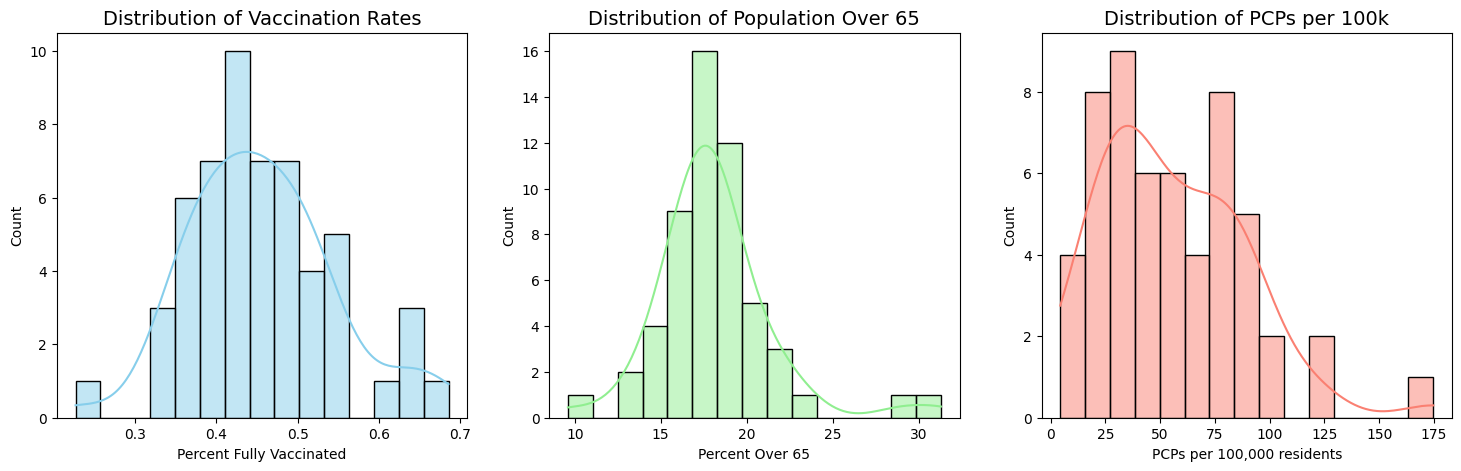

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=df, x='Percent of Population Completing Vaccination', 
             kde=True, ax=axes[0], color='skyblue', bins=15)
axes[0].set_title('Distribution of Vaccination Rates', fontsize=14)
axes[0].set_xlabel('Percent Fully Vaccinated')

sns.histplot(data=df, x='Percent of population over 65', 
             kde=True, ax=axes[1], color='lightgreen', bins=15)
axes[1].set_title('Distribution of Population Over 65', fontsize=14)
axes[1].set_xlabel('Percent Over 65')

sns.histplot(data=df, x='primary care providers per 100k', 
             kde=True, ax=axes[2], color='salmon', bins=15)
axes[2].set_title('Distribution of PCPs per 100k', fontsize=14)
axes[2].set_xlabel('PCPs per 100,000 residents')

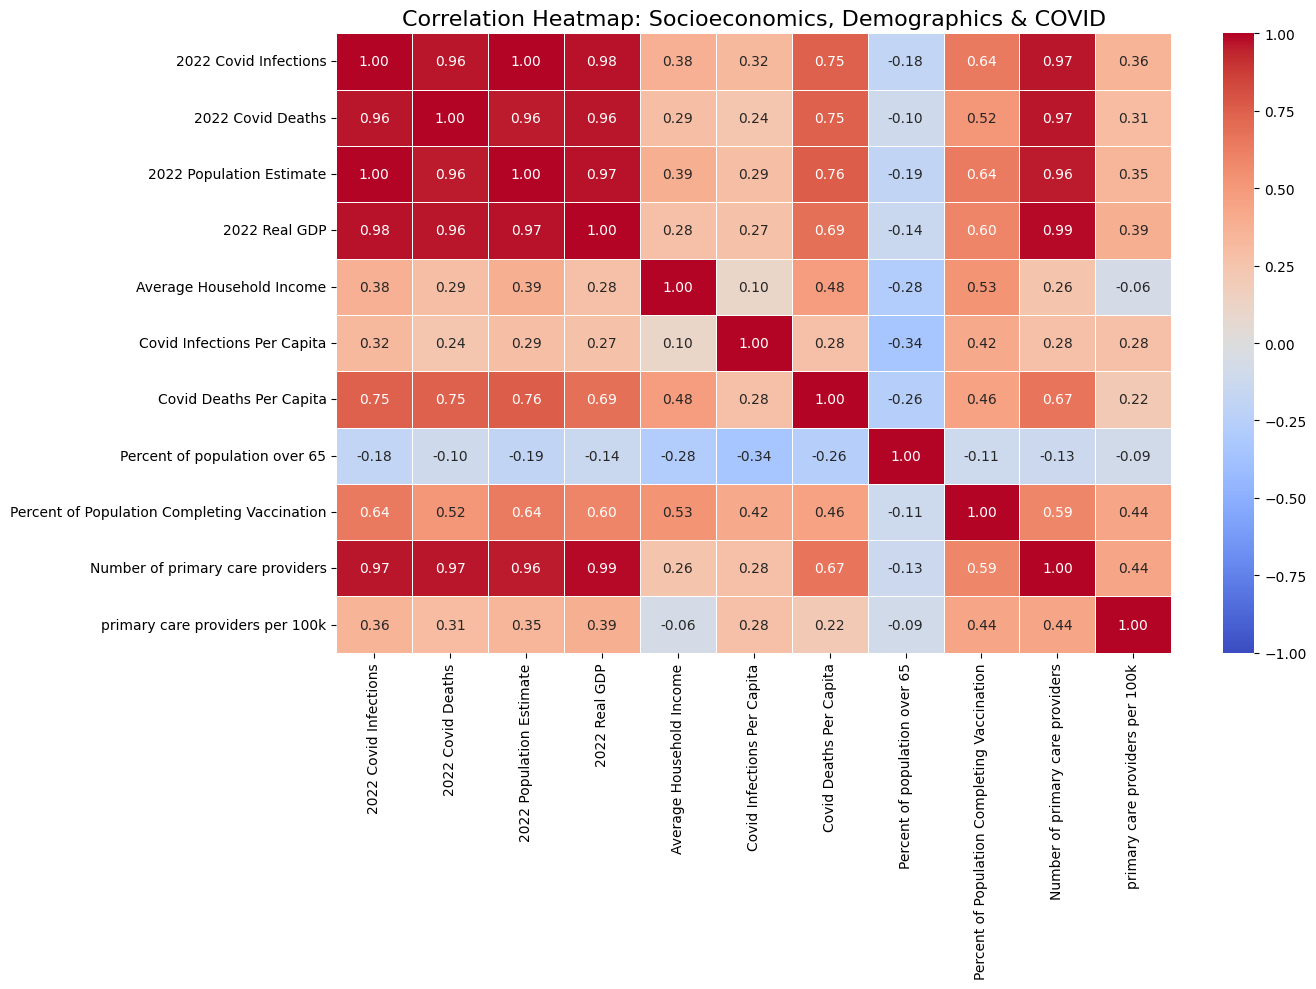

In [3]:
cols_to_drop = ['County', 'County FIPS Code']
corr_matrix = df.drop(columns=cols_to_drop).corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, 
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5, 
            vmin=-1, vmax=1)

plt.title('Correlation Heatmap: Socioeconomics, Demographics & COVID', fontsize=16)
plt.tight_layout()
plt.show()

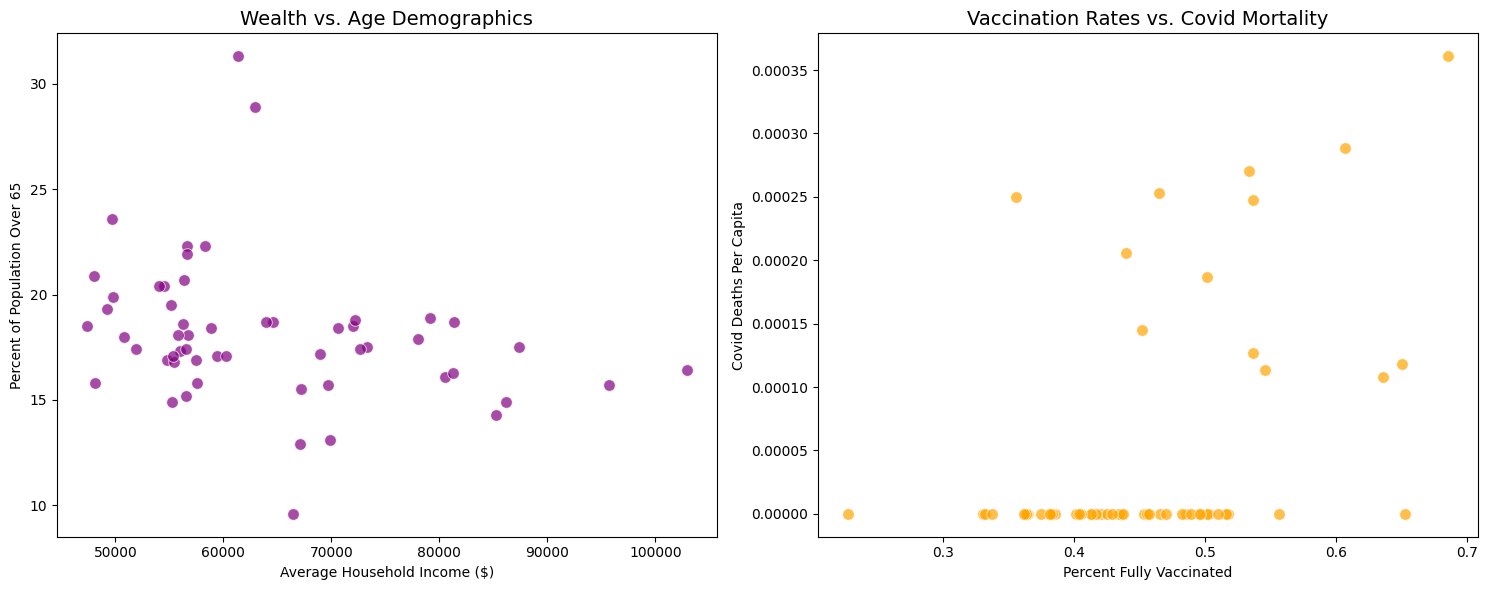

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

#income vs age
sns.scatterplot(data=df, 
                x='Average Household Income', 
                y='Percent of population over 65', 
                ax=axes[0], color='purple', s=70, alpha=0.7)
axes[0].set_title('Wealth vs. Age Demographics', fontsize=14)
axes[0].set_xlabel('Average Household Income ($)')
axes[0].set_ylabel('Percent of Population Over 65')

#vax vs deaths
sns.scatterplot(data=df, 
                x='Percent of Population Completing Vaccination', 
                y='Covid Deaths Per Capita', 
                ax=axes[1], color='orange', s=70, alpha=0.7)
axes[1].set_title('Vaccination Rates vs. Covid Mortality', fontsize=14)
axes[1].set_xlabel('Percent Fully Vaccinated')
axes[1].set_ylabel('Covid Deaths Per Capita')

plt.tight_layout()
plt.show()